# Experiment 2 Prompt-Format Repeated-Measures Analysis

This notebook analyzes Experiment 2: groundedness judging under three prompt formats.

The design is a repeated-measures prompt-format experiment. For each model and trace, the same groundedness task is judged using:

- `line`
- `json`
- `bullet`

The main analysis compares all three prompt formats at once rather than centering pairwise comparisons.

Primary analyses:

1. **Friedman test**: do the three prompt formats produce systematically different scores?
2. **Intraclass correlation (ICC)**: are the three prompt formats interchangeable in raw score values?
3. **Kendall's W**: do the three prompt formats rank traces similarly?

## Imports and Configuration

The notebook uses only local CSV files from `results /experiment 2`. No model inference is run here.

In [1]:
from __future__ import annotations

from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RESULTS_DIR = Path('results ') / 'experiment 2'
PROMPT_ORDER = ['line', 'json', 'bullet']
RANDOM_SEED = 42

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

## Statistical Helper Functions

### Friedman test

For each model, the Friedman test compares the three paired score columns: `line`, `json`, and `bullet`.

Null hypothesis:

```text
The score distributions are the same across the three prompt formats.
```

Alternative hypothesis:

```text
At least one prompt format differs.
```

### Kendall's W

Kendall's W is derived from the Friedman statistic:

```text
W = chi_square / (n_items * (k_formats - 1))
```

It ranges from 0 to 1:

```text
0 = no rank agreement
1 = perfect rank agreement
```

### ICC(A,1): two-way mixed absolute-agreement ICC

ICC treats prompt formats as repeated raters scoring the same traces. We use an absolute-agreement form because prompt formats should ideally produce the same score, not merely correlated scores.

Interpretation:

```text
high ICC = prompt formats are interchangeable in score values
low ICC = same trace can receive different scores depending on prompt format
```

In [2]:
def parse_bool(value) -> bool:
    if isinstance(value, bool):
        return value
    return str(value).strip().lower() in {'true', '1', 'yes'}


def format_table(df: pd.DataFrame, digits=4) -> pd.DataFrame:
    out = df.copy()
    number_cols = out.select_dtypes(include='number').columns
    out[number_cols] = out[number_cols].round(digits)
    return out


def make_prompt_score_matrix(group: pd.DataFrame) -> pd.DataFrame:
    pivot = group.pivot_table(
        index='trace_id',
        columns='prompt_format',
        values='score_num',
        aggfunc='mean',
    )
    missing = [fmt for fmt in PROMPT_ORDER if fmt not in pivot.columns]
    if missing:
        raise ValueError(f'Missing prompt format columns: {missing}')
    return pivot[PROMPT_ORDER].dropna()


def friedman_and_kendall_w(score_matrix: pd.DataFrame) -> pd.Series:
    n_items, k_formats = score_matrix.shape
    if n_items < 2 or k_formats < 3:
        return pd.Series({
            'n_traces_complete': n_items,
            'friedman_chi2': np.nan,
            'friedman_p': np.nan,
            'kendall_w': np.nan,
        })
    result = stats.friedmanchisquare(*(score_matrix[col] for col in score_matrix.columns))
    kendall_w = result.statistic / (n_items * (k_formats - 1))
    return pd.Series({
        'n_traces_complete': int(n_items),
        'friedman_chi2': float(result.statistic),
        'friedman_p': float(result.pvalue),
        'kendall_w': float(kendall_w),
    })


def icc_absolute_agreement_single(score_matrix: pd.DataFrame) -> float:
    """Two-way mixed absolute-agreement single-measure ICC, ICC(A,1).

    Rows are targets/traces and columns are fixed prompt formats. Formula follows
    the McGraw-Wong/Shrout-Fleiss absolute agreement ANOVA decomposition:

    ICC(A,1) = (MSR - MSE) / (MSR + (k - 1) * MSE + k * (MSC - MSE) / n)

    where MSR is target mean square, MSC is condition/rater mean square, and MSE
    is residual mean square.
    """
    x = score_matrix.to_numpy(dtype=float)
    n, k = x.shape
    if n < 2 or k < 2:
        return np.nan

    grand_mean = x.mean()
    row_means = x.mean(axis=1, keepdims=True)
    col_means = x.mean(axis=0, keepdims=True)

    ss_rows = k * np.sum((row_means - grand_mean) ** 2)
    ss_cols = n * np.sum((col_means - grand_mean) ** 2)
    ss_total = np.sum((x - grand_mean) ** 2)
    ss_error = ss_total - ss_rows - ss_cols

    ms_rows = ss_rows / (n - 1)
    ms_cols = ss_cols / (k - 1)
    ms_error = ss_error / ((n - 1) * (k - 1))

    denom = ms_rows + (k - 1) * ms_error + (k * (ms_cols - ms_error) / n)
    if np.isclose(denom, 0):
        return np.nan
    return float((ms_rows - ms_error) / denom)


def sensitivity_summary(score_matrix: pd.DataFrame) -> pd.Series:
    sensitivity = score_matrix.max(axis=1) - score_matrix.min(axis=1)
    return pd.Series({
        'mean_prompt_sensitivity': sensitivity.mean(),
        'median_prompt_sensitivity': sensitivity.median(),
        'p90_prompt_sensitivity': sensitivity.quantile(0.90),
        'pct_exactly_stable': (sensitivity == 0).mean(),
        'pct_sensitivity_ge_025': (sensitivity >= 0.25).mean(),
        'pct_sensitivity_ge_050': (sensitivity >= 0.50).mean(),
    })

# Load Results

Each Experiment 2 CSV is one model run. The expected structure is one row per model, trace, and prompt format.

In [3]:
csv_paths = sorted(RESULTS_DIR.glob('*.csv'))
if not csv_paths:
    raise FileNotFoundError(f'No CSV files found under {RESULTS_DIR.resolve()}')

frames = []
for path in csv_paths:
    df = pd.read_csv(path)
    required = {'model', 'trace_id', 'evaluator', 'prompt_format', 'level', 'score', 'latency_ms', 'is_skipped'}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f'{path.name} is missing expected columns: {sorted(missing)}')
    df['source_file'] = path.name
    df['score_num'] = pd.to_numeric(df['score'], errors='coerce')
    df['is_skipped_bool'] = df['is_skipped'].map(parse_bool)
    frames.append(df)

results = pd.concat(frames, ignore_index=True)
models = sorted(results['model'].unique())

print(f'Loaded {len(csv_paths)} CSV files')
print(f'Total rows: {len(results):,}')
print(f'Models: {len(models)}')
for model in models:
    print(f'  - {model}')

Loaded 3 CSV files
Total rows: 1,053
Models: 3
  - Qwen/Qwen3.5-2B
  - Qwen/Qwen3.5-9B
  - google/gemma-3-4b-it


# Data Sanity Checks

This verifies that the repeated-measures design is complete: each model should have the same traces scored under all three prompt formats.

In [4]:
san_summary = (
    results.groupby(['model', 'prompt_format'])
    .agg(
        rows=('trace_id', 'size'),
        traces=('trace_id', 'nunique'),
        valid_scores=('score_num', lambda s: int(s.notna().sum())),
        skipped=('is_skipped_bool', 'sum'),
        mean_score=('score_num', 'mean'),
        std_score=('score_num', 'std'),
        mean_latency_ms=('latency_ms', 'mean'),
    )
    .reset_index()
)
san_summary['valid_rate'] = san_summary['valid_scores'] / san_summary['rows']
format_table(san_summary.sort_values(['model', 'prompt_format']))

,model,prompt_format,rows,traces,valid_scores,skipped,mean_score,std_score,mean_latency_ms,valid_rate
0,Qwen/Qwen3.5-2B,bullet,117,117,117,0,0.0624,0.1196,2647.9329,1.0
1,Qwen/Qwen3.5-2B,json,117,117,117,0,0.0021,0.0231,2314.5614,1.0
2,Qwen/Qwen3.5-2B,line,117,117,117,0,0.0641,0.1803,2309.1308,1.0
3,Qwen/Qwen3.5-9B,bullet,117,117,117,0,0.0299,0.1320,3045.5904,1.0
4,Qwen/Qwen3.5-9B,json,117,117,117,0,0.0171,0.1302,3146.2687,1.0
5,Qwen/Qwen3.5-9B,line,117,117,117,0,0.0235,0.1392,3234.4052,1.0
6,google/gemma-3-4b-it,bullet,117,117,117,0,0.1197,0.2854,11715.6416,1.0
7,google/gemma-3-4b-it,json,117,117,117,0,0.1603,0.3512,11754.0004,1.0
8,google/gemma-3-4b-it,line,117,117,117,0,0.1282,0.3142,11950.9959,1.0


In [5]:
complete_rows = []
score_matrices = {}
for model, group in results[~results['is_skipped_bool'] & results['score_num'].notna()].groupby('model'):
    matrix = make_prompt_score_matrix(group)
    score_matrices[model] = matrix
    complete_rows.append({
        'model': model,
        'complete_traces': len(matrix),
        'line_present': 'line' in matrix.columns,
        'json_present': 'json' in matrix.columns,
        'bullet_present': 'bullet' in matrix.columns,
    })
complete_summary = pd.DataFrame(complete_rows)
complete_summary

,model,complete_traces,line_present,json_present,bullet_present
0,Qwen/Qwen3.5-2B,117,True,True,True
1,Qwen/Qwen3.5-9B,117,True,True,True
2,google/gemma-3-4b-it,117,True,True,True


# Score and Latency Distributions

These plots describe how each prompt format behaves before formal testing.

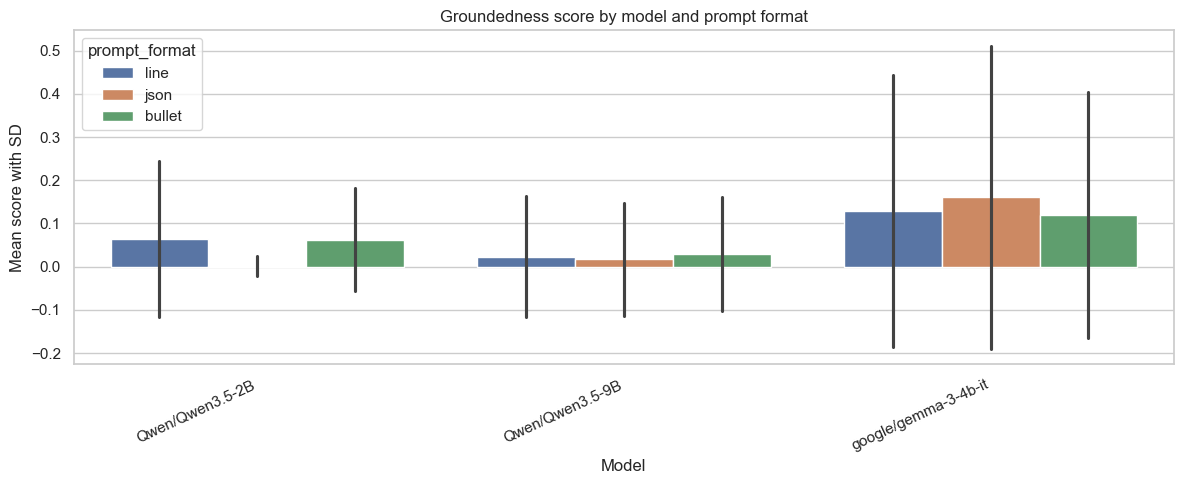

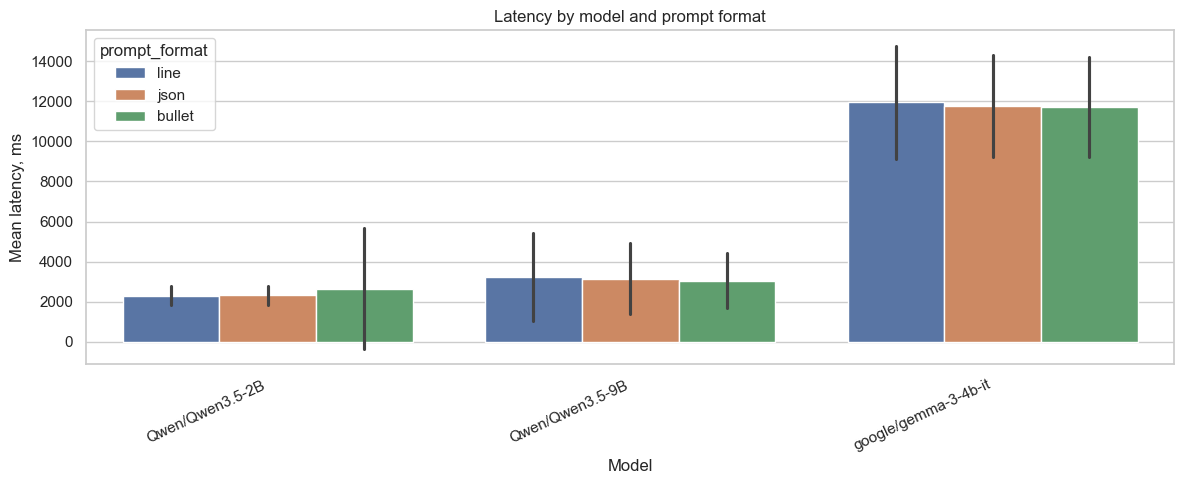

In [6]:
plt.figure(figsize=(12, 5))
sns.barplot(data=results, x='model', y='score_num', hue='prompt_format', hue_order=PROMPT_ORDER, errorbar='sd')
plt.xticks(rotation=25, ha='right')
plt.title('Groundedness score by model and prompt format')
plt.xlabel('Model')
plt.ylabel('Mean score with SD')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=results, x='model', y='latency_ms', hue='prompt_format', hue_order=PROMPT_ORDER, errorbar='sd')
plt.xticks(rotation=25, ha='right')
plt.title('Latency by model and prompt format')
plt.xlabel('Model')
plt.ylabel('Mean latency, ms')
plt.tight_layout()
plt.show()

# Analysis 1: Friedman Test

This is the primary all-three-format hypothesis test.

A significant p-value means the model's groundedness scores depend on prompt format. A non-significant p-value means there is no strong evidence of a systematic format-level shift, although individual traces may still have large differences.

In [7]:
analysis_rows = []
for model, matrix in score_matrices.items():
    row = friedman_and_kendall_w(matrix)
    row['model'] = model
    row['icc_absolute_agreement'] = icc_absolute_agreement_single(matrix)
    row = pd.concat([row, sensitivity_summary(matrix)])
    analysis_rows.append(row)

all_three_summary = pd.DataFrame(analysis_rows)
cols = ['model', 'n_traces_complete', 'friedman_chi2', 'friedman_p', 'kendall_w', 'icc_absolute_agreement',
        'mean_prompt_sensitivity', 'median_prompt_sensitivity', 'p90_prompt_sensitivity',
        'pct_exactly_stable', 'pct_sensitivity_ge_025', 'pct_sensitivity_ge_050']
all_three_summary = all_three_summary[cols]
format_table(all_three_summary.sort_values('mean_prompt_sensitivity'))

,model,n_traces_complete,friedman_chi2,friedman_p,kendall_w,icc_absolute_agreement,mean_prompt_sensitivity,median_prompt_sensitivity,p90_prompt_sensitivity,pct_exactly_stable,pct_sensitivity_ge_025,pct_sensitivity_ge_050
1,Qwen/Qwen3.5-9B,117.0,2.4800,0.2894,0.0106,0.3418,0.0470,0.0,0.00,0.9316,0.0684,0.0598
0,Qwen/Qwen3.5-2B,117.0,30.8824,0.0000,0.1320,0.1488,0.0966,0.0,0.25,0.7179,0.2821,0.0513
2,google/gemma-3-4b-it,117.0,3.2889,0.1931,0.0141,0.6715,0.1432,0.0,0.75,0.7692,0.2308,0.1453


# Analysis 2: Intraclass Correlation Across Prompt Formats

ICC measures whether the three prompt formats are interchangeable in actual score values.

Interpretation guide:

```text
ICC near 1.0: high score agreement across prompt formats
ICC around 0.5: moderate agreement
ICC near 0.0: low agreement
ICC below 0.0: disagreement is worse than expected from the ANOVA decomposition
```

Because this is absolute-agreement ICC, a prompt format that systematically scores higher/lower will reduce ICC.

In [8]:
icc_table = all_three_summary[['model', 'n_traces_complete', 'icc_absolute_agreement']].copy()
format_table(icc_table.sort_values('icc_absolute_agreement', ascending=False))

,model,n_traces_complete,icc_absolute_agreement
2,google/gemma-3-4b-it,117.0,0.6715
1,Qwen/Qwen3.5-9B,117.0,0.3418
0,Qwen/Qwen3.5-2B,117.0,0.1488


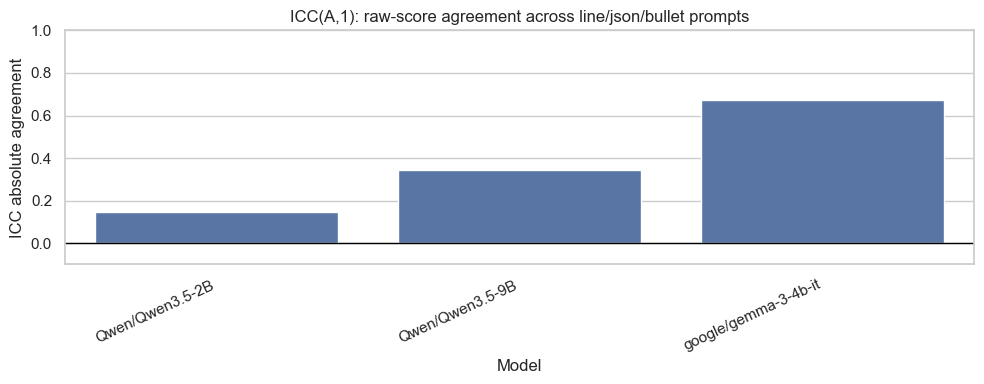

In [9]:
plt.figure(figsize=(10, 4))
sns.barplot(data=icc_table, x='model', y='icc_absolute_agreement')
plt.axhline(0, color='black', linewidth=1)
plt.ylim(min(-0.1, icc_table['icc_absolute_agreement'].min() - 0.05), 1.0)
plt.xticks(rotation=25, ha='right')
plt.title('ICC(A,1): raw-score agreement across line/json/bullet prompts')
plt.xlabel('Model')
plt.ylabel('ICC absolute agreement')
plt.tight_layout()
plt.show()

# Analysis 3: Kendall's W Across Prompt Formats

Kendall's W measures whether the three prompt formats rank traces similarly.

This is different from ICC:

```text
ICC: do formats give similar score values?
Kendall's W: do formats rank traces similarly?
```

A model can have decent ranking agreement but poor score agreement if one format is consistently more lenient or harsh.

In [10]:
kendall_table = all_three_summary[['model', 'n_traces_complete', 'friedman_chi2', 'friedman_p', 'kendall_w']].copy()
format_table(kendall_table.sort_values('kendall_w', ascending=False))

,model,n_traces_complete,friedman_chi2,friedman_p,kendall_w
0,Qwen/Qwen3.5-2B,117.0,30.8824,0.0000,0.1320
2,google/gemma-3-4b-it,117.0,3.2889,0.1931,0.0141
1,Qwen/Qwen3.5-9B,117.0,2.4800,0.2894,0.0106


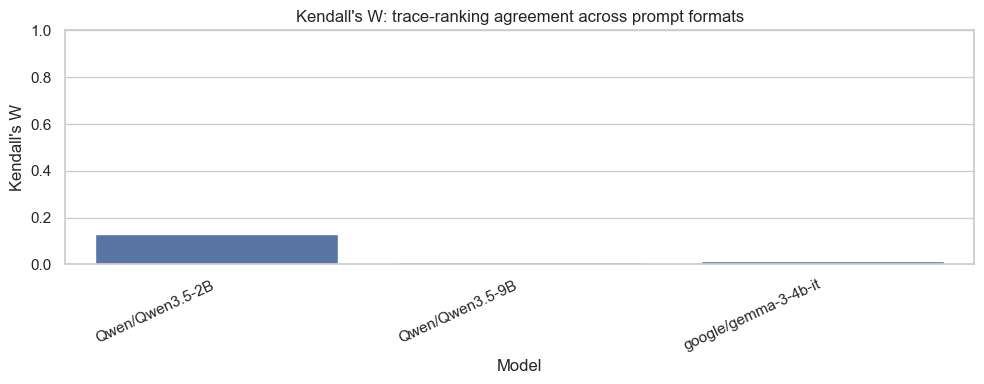

In [11]:
plt.figure(figsize=(10, 4))
sns.barplot(data=kendall_table, x='model', y='kendall_w')
plt.ylim(0, 1)
plt.xticks(rotation=25, ha='right')
plt.title("Kendall's W: trace-ranking agreement across prompt formats")
plt.xlabel('Model')
plt.ylabel("Kendall's W")
plt.tight_layout()
plt.show()

# Prompt Sensitivity Cases

Even when the overall Friedman test is not significant, individual traces can still be highly sensitive to prompt format. This table surfaces the largest disagreements for qualitative inspection.

In [12]:
top_cases = []
for model, matrix in score_matrices.items():
    case_df = matrix.copy()
    case_df['model'] = model
    case_df['prompt_sensitivity'] = matrix.max(axis=1) - matrix.min(axis=1)
    case_df['highest_format'] = matrix.idxmax(axis=1)
    case_df['lowest_format'] = matrix.idxmin(axis=1)
    top_cases.append(case_df.reset_index())

top_cases = pd.concat(top_cases, ignore_index=True)
format_table(top_cases.sort_values(['prompt_sensitivity'], ascending=False).head(30))

prompt_format,trace_id,line,json,bullet,model,prompt_sensitivity,highest_format,lowest_format
101,e7d5dd0d36db95a40a4fbe258edd0aba,1.00,0.00,0.00,Qwen/Qwen3.5-2B,1.00,line,json
342,f2de3b74884dc2312bb0fbf7c9867a9c,0.00,1.00,0.00,google/gemma-3-4b-it,1.00,json,line
316,b69bcf49516121f03e5809cbd776c21f,1.00,0.00,0.50,google/gemma-3-4b-it,1.00,line,json
315,b5576ffca7ad7cce0fc34b5aad7fc543,1.00,0.00,1.00,google/gemma-3-4b-it,1.00,line,json
313,b1f9b9baefa4c69d1d848e35c130e29d,0.00,1.00,0.25,google/gemma-3-4b-it,1.00,json,line
221,ee9335fbe7329b273a8d922bd3f73b84,0.00,0.00,1.00,Qwen/Qwen3.5-9B,1.00,bullet,line
106,ef0207e4427fe22aeb1c2105932b74d7,1.00,0.00,0.25,Qwen/Qwen3.5-2B,1.00,line,json
225,f2de3b74884dc2312bb0fbf7c9867a9c,0.00,1.00,0.00,Qwen/Qwen3.5-9B,1.00,json,line
306,a5c2947f441d65edf60131463fb79999,0.50,1.00,0.00,google/gemma-3-4b-it,1.00,json,bullet
236,01c5727165fc43899b3b594b9bef5f19,1.00,0.00,0.75,google/gemma-3-4b-it,1.00,line,json


# Interpretation Checklist

Use the three main statistics together:

- **Friedman significant + low ICC**: strong evidence that prompt format changes score values.
- **High Kendall's W + low ICC**: formats rank traces similarly but use different score scales.
- **Low Kendall's W + low ICC**: prompt format changes both scores and rankings.
- **Low mean sensitivity + high ICC/W**: model is robust to prompt format.

This notebook intentionally keeps pairwise prompt comparisons out of the main analysis. Pairwise post-hoc tests can be added later only for models where the Friedman test is significant.